# Comparativa Integral de Experimentos (Conjunto de Test)

## Tesis: Prediccion de Enfermedad Cardiovascular

Este notebook realiza una evaluacion comparativa y reproducible de todos los experimentos registrados en el proyecto.
La comparacion se ejecuta exclusivamente sobre el conjunto de test, evitando re-optimizacion en prueba.

### Objetivos
1. Consolidar el rendimiento de todos los modelos y experimentos.
2. Comparar estabilidad entre validacion y test (Delta Test-Val).
3. Analizar caracteristicas del conjunto de test y relevancia de variables.
4. Identificar el modelo campeon global y campeones por experimento.

## 1. Importacion de librerias y configuracion
Se define una configuracion visual sobria para reporte academico y rutas robustas del proyecto.

In [21]:
import json
import re
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    roc_curve,
    confusion_matrix,
    classification_report,
)

def find_project_root(start: Path) -> Path:
    for root in [start, *start.parents]:
        if (root / 'models').exists() and (root / 'data').exists() and (root / 'notebooks').exists():
            return root
    raise FileNotFoundError('No se encontro la raiz del proyecto. Abra este notebook dentro del workspace del proyecto.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
MODELS_ROOT = PROJECT_ROOT / 'models'
TEST_INPUT_DIR = PROJECT_ROOT / 'data' / 'processed' / 'model_inputs'
REPORT_DIR = PROJECT_ROOT / 'report'
FIGURES_DIR = REPORT_DIR / 'figures'
TABLES_DIR = REPORT_DIR / 'tables'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 140
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11

MODEL_MAP = {
    'LR': 'Logistic Regression',
    'RF': 'Random Forest',
    'XGB': 'XGBoost',
    'LGBM': 'LightGBM',
}
MODEL_ORDER = [MODEL_MAP[k] for k in ['LR', 'RF', 'XGB', 'LGBM']]

print(f'Raiz de proyecto: {PROJECT_ROOT}')
print(f'Directorio de tablas: {TABLES_DIR}')
print(f'Directorio de figuras: {FIGURES_DIR}')

Raiz de proyecto: C:\Users\LENOVO\Documents\Jhandry U\Prediccion_Cardiovascular
Directorio de tablas: C:\Users\LENOVO\Documents\Jhandry U\Prediccion_Cardiovascular\report\tables
Directorio de figuras: C:\Users\LENOVO\Documents\Jhandry U\Prediccion_Cardiovascular\report\figures


## 2. Carga del conjunto de test y experimentos
Se cargan datos de prueba, se valida consistencia y se detectan automaticamente todos los directorios ExperimentoN.

In [22]:
X_test = pd.read_csv(TEST_INPUT_DIR / 'X_test.csv')
y_test = pd.read_csv(TEST_INPUT_DIR / 'y_test.csv').values.ravel()

assert X_test.shape[0] == y_test.shape[0], 'X_test y y_test tienen diferente numero de filas.'
assert X_test.isnull().sum().sum() == 0, 'X_test contiene valores nulos.'

exp_pattern = re.compile(r'^Experimento(\d+)$')
experiment_dirs = []
for item in MODELS_ROOT.iterdir():
    if item.is_dir() and exp_pattern.match(item.name):
        experiment_dirs.append(item)
experiment_dirs = sorted(experiment_dirs, key=lambda p: int(exp_pattern.match(p.name).group(1)))

if not experiment_dirs:
    raise FileNotFoundError('No se encontraron directorios ExperimentoN dentro de models/.')

class_counts = pd.Series(y_test).value_counts().sort_index()
test_info = pd.DataFrame({
    'n_registros': [X_test.shape[0]],
    'n_variables': [X_test.shape[1]],
    'clase_0': [int(class_counts.get(0, 0))],
    'clase_1': [int(class_counts.get(1, 0))],
    'pct_clase_1': [float((y_test == 1).mean() * 100)],
})

display(test_info)
print('Experimentos detectados:', [p.name for p in experiment_dirs])

,n_registros,n_variables,clase_0,clase_1,pct_clase_1
0,6853,25,3462,3391,49.481979


Experimentos detectados: ['Experimento1', 'Experimento2', 'Experimento3', 'Experimento4', 'Experimento5', 'Experimento6', 'Experimento7', 'Experimento8', 'Experimento9', 'Experimento10', 'Experimento11', 'Experimento12', 'Experimento13', 'Experimento14', 'Experimento15', 'Experimento16', 'Experimento17']


## 3. Funciones auxiliares de evaluacion
Se define lectura robusta de umbrales y metricas de validacion para estimar brecha de generalizacion en test.

In [23]:
def load_threshold(artifacts_dir: Path, model_key: str) -> tuple[float, str]:
    threshold_path = artifacts_dir / f'threshold_{model_key}.json'
    if threshold_path.exists():
        with open(threshold_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        return float(data.get('best_threshold', 0.5)), 'validation_tuned'
    return 0.5, 'default_0.5'

def load_val_auc(artifacts_dir: Path, model_key: str) -> float:
    val_metrics_path = artifacts_dir / f'val_metrics_{model_key}.csv'
    if not val_metrics_path.exists():
        return np.nan
    df_val = pd.read_csv(val_metrics_path)
    if df_val.empty or 'val_roc_auc' not in df_val.columns:
        return np.nan
    return float(df_val.loc[0, 'val_roc_auc'])

def load_training_metadata(artifacts_dir: Path, model_key: str, default_cv_folds: float = np.nan) -> tuple[float, float, str, float, float, float]:
    trials_path = artifacts_dir / f'optuna_trials_{model_key}.csv'
    val_metrics_path = artifacts_dir / f'val_metrics_{model_key}.csv'
    best_params_path = artifacts_dir / f'best_params_{model_key}.json'

    n_trials = np.nan
    cv_folds = float(default_cv_folds) if not np.isnan(default_cv_folds) else np.nan
    source = 'default_cv_folds' if not np.isnan(cv_folds) else 'cv_folds_no_disponible'
    best_trial_number = np.nan
    search_time_seconds = np.nan
    train_time_seconds = np.nan

    if trials_path.exists():
        trials_df = pd.read_csv(trials_path)
        if not trials_df.empty:
            if 'number' in trials_df.columns:
                n_trials = float(trials_df['number'].max() + 1)
            else:
                n_trials = float(len(trials_df))

            for col in ['user_attrs_cv_folds', 'params_cv_folds', 'cv_folds', 'n_splits']:
                if col in trials_df.columns:
                    fold_values = pd.to_numeric(trials_df[col], errors='coerce').dropna()
                    if not fold_values.empty:
                        cv_folds = float(fold_values.iloc[0])
                        source = f'optuna_trials:{col}'
                        break

            if 'number' in trials_df.columns and 'value' in trials_df.columns:
                trial_rank_df = trials_df.copy()
                if 'state' in trial_rank_df.columns:
                    complete_mask = trial_rank_df['state'].astype(str).str.upper().str.contains('COMPLETE')
                    if complete_mask.any():
                        trial_rank_df = trial_rank_df.loc[complete_mask]
                trial_rank_df = trial_rank_df.dropna(subset=['number', 'value'])
                if not trial_rank_df.empty:
                    trial_rank_df['value'] = pd.to_numeric(trial_rank_df['value'], errors='coerce')
                    trial_rank_df = trial_rank_df.dropna(subset=['value'])
                    if not trial_rank_df.empty:
                        best_idx = trial_rank_df['value'].idxmax()
                        best_trial_number = float(trial_rank_df.loc[best_idx, 'number'])

    if val_metrics_path.exists():
        df_val = pd.read_csv(val_metrics_path)
        if not df_val.empty:
            for col in ['cv_folds', 'n_splits', 'folds']:
                if col in df_val.columns:
                    fold_values = pd.to_numeric(df_val[col], errors='coerce').dropna()
                    if not fold_values.empty:
                        cv_folds = float(fold_values.iloc[0])
                        source = f'val_metrics:{col}'
                        break

            if 'best_trial_number' in df_val.columns:
                trial_values = pd.to_numeric(df_val['best_trial_number'], errors='coerce').dropna()
                if not trial_values.empty:
                    best_trial_number = float(trial_values.iloc[0])

            if 'optuna_total_search_seconds' in df_val.columns:
                search_values = pd.to_numeric(df_val['optuna_total_search_seconds'], errors='coerce').dropna()
                if not search_values.empty:
                    search_time_seconds = float(search_values.iloc[0])

            if 'best_params_fit_seconds' in df_val.columns:
                fit_values = pd.to_numeric(df_val['best_params_fit_seconds'], errors='coerce').dropna()
                if not fit_values.empty:
                    train_time_seconds = float(fit_values.iloc[0])

            if np.isnan(train_time_seconds) and 'best_params_train_eval_total_seconds' in df_val.columns:
                train_values = pd.to_numeric(df_val['best_params_train_eval_total_seconds'], errors='coerce').dropna()
                if not train_values.empty:
                    train_time_seconds = float(train_values.iloc[0])

    if np.isnan(best_trial_number) and best_params_path.exists():
        with open(best_params_path, 'r', encoding='utf-8') as f:
            params = json.load(f)
        for key in ['best_trial_number', 'best_trial']:
            if key in params:
                try:
                    best_trial_number = float(params[key])
                    break
                except (TypeError, ValueError):
                    pass

    return cv_folds, n_trials, source, best_trial_number, search_time_seconds, train_time_seconds

def align_X_test_for_model(model, X_test_base: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    if not hasattr(model, 'feature_names_in_'):
        return X_test_base, []

    expected = list(model.feature_names_in_)
    missing = [c for c in expected if c not in X_test_base.columns]
    if missing:
        return X_test_base, missing

    X_aligned = X_test_base.loc[:, expected]
    return X_aligned, []

def _build_default_full_feature_snapshot(snapshot_cache: dict) -> tuple[pd.DataFrame, np.ndarray]:
    cache_key = 'default_full_feature_snapshot'
    if cache_key in snapshot_cache:
        return snapshot_cache[cache_key]

    import subprocess
    import sys

    tmp_output_dir = PROJECT_ROOT / 'data' / 'processed' / '__tmp_full_feature_snapshot'
    tmp_scaler_path = PROJECT_ROOT / 'models' / '__tmp_full_feature_scaler.joblib'

    cmd = [
        sys.executable,
        str(PROJECT_ROOT / 'src' / 'features' / 'build_features.py'),
        '--input', str(PROJECT_ROOT / 'data' / 'processed' / 'cardio_clean.csv'),
        '--output_dir', str(tmp_output_dir),
        '--scaler_path', str(tmp_scaler_path),
        '--scaler_type', 'robust',
    ]

    subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    X_test_full = pd.read_csv(tmp_output_dir / 'X_test.csv')
    y_test_full = pd.read_csv(tmp_output_dir / 'y_test.csv').values.ravel()

    snapshot_cache[cache_key] = (X_test_full, y_test_full)
    return X_test_full, y_test_full

def resolve_test_snapshot_for_model(
    exp_dir: Path,
    model,
    X_test_global: pd.DataFrame,
    y_test_global: np.ndarray,
    snapshot_cache: dict,
) -> tuple[pd.DataFrame, np.ndarray, str, list[str]]:
    artifacts_dir = exp_dir / 'training_artifacts'
    snapshot_dir = artifacts_dir / 'model_inputs_snapshot'
    snapshot_x_path = snapshot_dir / 'X_test.csv'
    snapshot_y_path = snapshot_dir / 'y_test.csv'

    expected = list(model.feature_names_in_) if hasattr(model, 'feature_names_in_') else list(X_test_global.columns)

    def missing_from(X_candidate: pd.DataFrame) -> list[str]:
        return [c for c in expected if c not in X_candidate.columns]

    if snapshot_x_path.exists() and snapshot_y_path.exists():
        X_snap = pd.read_csv(snapshot_x_path)
        y_snap = pd.read_csv(snapshot_y_path).values.ravel()
        missing_snap = missing_from(X_snap)
        if not missing_snap:
            return X_snap.loc[:, expected], y_snap, 'snapshot_existente', []

    missing_global = missing_from(X_test_global)
    if not missing_global:
        snapshot_dir.mkdir(parents=True, exist_ok=True)
        X_save = X_test_global.loc[:, expected].copy()
        y_save = y_test_global.copy()
        X_save.to_csv(snapshot_x_path, index=False)
        pd.DataFrame({'cardio': y_save}).to_csv(snapshot_y_path, index=False)
        return X_save, y_save, 'snapshot_desde_global', []

    try:
        X_full, y_full = _build_default_full_feature_snapshot(snapshot_cache)
        missing_full = missing_from(X_full)
        if not missing_full:
            snapshot_dir.mkdir(parents=True, exist_ok=True)
            X_save = X_full.loc[:, expected].copy()
            y_save = y_full.copy()
            X_save.to_csv(snapshot_x_path, index=False)
            pd.DataFrame({'cardio': y_save}).to_csv(snapshot_y_path, index=False)
            return X_save, y_save, 'snapshot_reconstruido_full_features', []
        return X_test_global, y_test_global, 'sin_snapshot', missing_full
    except Exception:
        return X_test_global, y_test_global, 'sin_snapshot', missing_global

def predict_proba_safe(model, X: pd.DataFrame) -> np.ndarray:
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        scores = model.decision_function(X)
        return 1.0 / (1.0 + np.exp(-scores))
    raise AttributeError('El modelo no expone predict_proba ni decision_function.')

def extract_feature_importance(model, feature_names: list[str]) -> pd.DataFrame | None:
    values = None
    if hasattr(model, 'feature_importances_'):
        values = np.asarray(model.feature_importances_, dtype=float)
    elif hasattr(model, 'coef_'):
        values = np.abs(np.asarray(model.coef_).reshape(-1))

    if values is None:
        return None

    values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
    total = values.sum()
    if total > 0:
        values = values / total

    imp_df = pd.DataFrame({'feature': feature_names, 'importance': values})
    imp_df = imp_df.sort_values('importance', ascending=False).reset_index(drop=True)
    return imp_df

def evaluate_model(y_true: np.ndarray, y_proba: np.ndarray, threshold: float) -> dict:
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'test_accuracy': accuracy_score(y_true, y_pred),
        'test_precision': precision_score(y_true, y_pred, zero_division=0),
        'test_recall': recall_score(y_true, y_pred, zero_division=0),
        'test_f1': f1_score(y_true, y_pred, zero_division=0),
        'test_roc_auc': roc_auc_score(y_true, y_proba),
        'test_mcc': matthews_corrcoef(y_true, y_pred),
        'y_pred': y_pred,
    }

## 4. Evaluacion de todos los experimentos en test
Para cada ExperimentoN y cada algoritmo, se calcula rendimiento en test aplicando su umbral almacenado.

In [24]:
records = []
pred_store = {}
importance_store = {}
skipped_models = []
snapshot_cache = {}

for exp_dir in experiment_dirs:
    exp_name = exp_dir.name
    artifacts_dir = exp_dir / 'training_artifacts'

    for model_key, model_name in MODEL_MAP.items():
        model_path = exp_dir / f'best_model_{model_key}.joblib'
        if not model_path.exists():
            continue

        model = joblib.load(model_path)

        X_eval, y_eval, snapshot_source, missing_features = resolve_test_snapshot_for_model(
            exp_dir=exp_dir,
            model=model,
            X_test_global=X_test,
            y_test_global=y_test,
            snapshot_cache=snapshot_cache,
        )

        if missing_features:
            skipped_models.append({
                'experiment': exp_name,
                'model_key': model_key,
                'model_name': model_name,
                'snapshot_source': snapshot_source,
                'reason': f'features no disponibles: {missing_features[:8]}'
            })
            print(
                f"[SKIP] {exp_name} | {model_name}: no se pudo construir snapshot compatible. "
                f"Faltan {len(missing_features)} columnas."
            )
            continue

        threshold, threshold_source = load_threshold(artifacts_dir, model_key)
        val_auc = load_val_auc(artifacts_dir, model_key)
        cv_folds, n_trials, cv_source, best_trial_number, search_time_seconds, train_time_seconds = load_training_metadata(artifacts_dir, model_key)
        y_proba = predict_proba_safe(model, X_eval)
        eval_dict = evaluate_model(y_eval, y_proba, threshold)

        delta_test_val = eval_dict['test_roc_auc'] - val_auc if not np.isnan(val_auc) else np.nan

        row = {
            'experiment': exp_name,
            'experiment_number': int(exp_pattern.match(exp_name).group(1)),
            'model_key': model_key,
            'model_name': model_name,
            'snapshot_source': snapshot_source,
            'n_test_snapshot': int(len(y_eval)),
            'threshold': threshold,
            'threshold_source': threshold_source,
            'cv_folds': cv_folds,
            'n_trials': n_trials,
            'cv_source': cv_source,
            'best_trial_number': best_trial_number,
            'search_time_seconds': search_time_seconds,
            'train_time_seconds': train_time_seconds,
            'val_roc_auc': val_auc,
            'delta_test_val_auc': delta_test_val,
            'test_accuracy': eval_dict['test_accuracy'],
            'test_precision': eval_dict['test_precision'],
            'test_recall': eval_dict['test_recall'],
            'test_f1': eval_dict['test_f1'],
            'test_roc_auc': eval_dict['test_roc_auc'],
            'test_mcc': eval_dict['test_mcc'],
        }
        records.append(row)

        pred_store[(exp_name, model_key)] = {
            'y_true': y_eval,
            'y_proba': y_proba,
            'y_pred': eval_dict['y_pred'],
            'model_name': model_name,
            'snapshot_source': snapshot_source,
        }

        fi_df = extract_feature_importance(model, X_eval.columns.tolist())
        if fi_df is not None:
            fi_df['experiment'] = exp_name
            fi_df['model_key'] = model_key
            fi_df['model_name'] = model_name
            importance_store[(exp_name, model_key)] = fi_df

results_df = pd.DataFrame(records)
if results_df.empty:
    if skipped_models:
        raise RuntimeError(
            'No se pudieron evaluar modelos por incompatibilidad de features entre experimentos. '
            'No fue posible construir snapshots compatibles con los modelos existentes.'
        )
    raise RuntimeError('No se pudieron evaluar modelos. Verifique que existan archivos best_model_*.joblib en cada experimento.')

results_df = results_df.sort_values(
    ['test_roc_auc', 'test_f1', 'test_mcc'],
    ascending=[False, False, False]
).reset_index(drop=True)

winners_df = (
    results_df.sort_values(['experiment_number', 'test_roc_auc', 'test_f1'], ascending=[True, False, False])
    .groupby('experiment', as_index=False)
    .first()
    .sort_values('experiment_number')
    .reset_index(drop=True)
)

champion_row = results_df.iloc[0]

print(f'Modelos evaluados: {len(results_df)}')
print(f'Experimentos cubiertos: {results_df["experiment"].nunique()}')
if skipped_models:
    print(f'Modelos omitidos por incompatibilidad de features: {len(skipped_models)}')
unknown_cv = int(results_df['cv_folds'].isna().sum())
if unknown_cv:
    print(f'Modelos con Folds CV no disponibles en artifacts: {unknown_cv}')
print('Campeon global:', champion_row['experiment'], '-', champion_row['model_name'])

Modelos evaluados: 68
Experimentos cubiertos: 17
Campeon global: Experimento17 - XGBoost


## 5. Tablas de comparacion formal

In [25]:
ranking_df = results_df[[
    'experiment', 'experiment_number', 'model_name', 'cv_folds', 'n_trials', 'best_trial_number', 'search_time_seconds', 'train_time_seconds', 'test_roc_auc', 'test_f1'
]].copy()
ranking_df = ranking_df.sort_values(['test_roc_auc', 'test_f1'], ascending=[False, False]).reset_index(drop=True)
ranking_df['experiment_abbr'] = ranking_df['experiment_number'].apply(lambda n: f'Exp{int(n)}')

ranking_df = ranking_df[[
    'experiment_abbr', 'experiment', 'model_name', 'cv_folds', 'n_trials', 'best_trial_number', 'search_time_seconds', 'train_time_seconds', 'test_roc_auc', 'test_f1'
]].rename(columns={
    'experiment_abbr': 'Experimento',
    'experiment': 'Directorio',
    'model_name': 'Modelo',
    'cv_folds': 'Folds CV',
    'n_trials': 'N Trials',
    'best_trial_number': 'Mejor Trial',
    'search_time_seconds': 'Tiempo busqueda (s)',
    'train_time_seconds': 'Tiempo entrenamiento (s)',
    'test_roc_auc': 'AUC-ROC (test)',
    'test_f1': 'F1-score (test)',
})

ranking_df['Folds CV'] = ranking_df['Folds CV'].round(0).astype('Int64')
ranking_df['N Trials'] = ranking_df['N Trials'].round(0).astype('Int64')
ranking_df['Mejor Trial'] = ranking_df['Mejor Trial'].round(0).astype('Int64')

print('Ranking global en test (solo metricas principales):')
display(
    ranking_df.style
    .format({
        'AUC-ROC (test)': '{:.4f}',
        'F1-score (test)': '{:.4f}',
        'Tiempo busqueda (s)': lambda v: '-' if pd.isna(v) else f'{v:.2f}',
        'Tiempo entrenamiento (s)': lambda v: '-' if pd.isna(v) else f'{v:.2f}',
    })
    .background_gradient(subset=['AUC-ROC (test)'], cmap='Blues')
    .background_gradient(subset=['F1-score (test)'], cmap='Greens')
)

winners_display = winners_df[[
    'experiment', 'experiment_number', 'model_name', 'cv_folds', 'n_trials', 'best_trial_number', 'search_time_seconds', 'train_time_seconds', 'test_roc_auc', 'test_f1'
]].copy()
winners_display['experiment_abbr'] = winners_display['experiment_number'].apply(lambda n: f'Exp{int(n)}')
winners_display = winners_display[[
    'experiment_abbr', 'experiment', 'model_name', 'cv_folds', 'n_trials', 'best_trial_number', 'search_time_seconds', 'train_time_seconds', 'test_roc_auc', 'test_f1'
]].rename(columns={
    'experiment_abbr': 'Experimento',
    'experiment': 'Directorio',
    'model_name': 'Modelo ganador',
    'cv_folds': 'Folds CV',
    'n_trials': 'N Trials',
    'best_trial_number': 'Mejor Trial',
    'search_time_seconds': 'Tiempo busqueda (s)',
    'train_time_seconds': 'Tiempo entrenamiento (s)',
    'test_roc_auc': 'AUC-ROC (test)',
    'test_f1': 'F1-score (test)',
})

winners_display['Folds CV'] = winners_display['Folds CV'].round(0).astype('Int64')
winners_display['N Trials'] = winners_display['N Trials'].round(0).astype('Int64')
winners_display['Mejor Trial'] = winners_display['Mejor Trial'].round(0).astype('Int64')

print('Modelo ganador por experimento:')
display(
    winners_display.style
    .format({
        'AUC-ROC (test)': '{:.4f}',
        'F1-score (test)': '{:.4f}',
        'Tiempo busqueda (s)': lambda v: '-' if pd.isna(v) else f'{v:.2f}',
        'Tiempo entrenamiento (s)': lambda v: '-' if pd.isna(v) else f'{v:.2f}',
    })
    .background_gradient(subset=['AUC-ROC (test)'], cmap='Blues')
    .background_gradient(subset=['F1-score (test)'], cmap='Greens')
)

Ranking global en test (solo metricas principales):


,Experimento,Directorio,Modelo,Folds CV,N Trials,Mejor Trial,Tiempo busqueda (s),Tiempo entrenamiento (s),AUC-ROC (test),F1-score (test)
0,Exp17,Experimento17,XGBoost,5,10,5,177.68,6.89,0.8059,0.7418
1,Exp8,Experimento8,XGBoost,5,10,5,159.05,7.14,0.8059,0.7419
2,Exp9,Experimento9,XGBoost,5,30,5,566.49,5.82,0.8059,0.7419
3,Exp14,Experimento14,XGBoost,5,50,5,1009.07,6.25,0.8059,0.7419
4,Exp15,Experimento15,XGBoost,5,30,5,480.36,3.84,0.8059,0.7419
5,Exp11,Experimento11,XGBoost,5,10,5,141.18,5.35,0.8058,0.7418
6,Exp10,Experimento10,XGBoost,5,10,5,141.91,5.46,0.8057,0.7407
7,Exp1,Experimento1,XGBoost,5,5,4,58.82,1.81,0.8056,0.7424
8,Exp2,Experimento2,XGBoost,10,5,4,108.02,2.05,0.8056,0.7424
9,Exp16,Experimento16,XGBoost,5,10,5,114.60,3.05,0.8056,0.7422


Modelo ganador por experimento:


,Experimento,Directorio,Modelo ganador,Folds CV,N Trials,Mejor Trial,Tiempo busqueda (s),Tiempo entrenamiento (s),AUC-ROC (test),F1-score (test)
0,Exp1,Experimento1,XGBoost,5,5,4,58.82,1.81,0.8056,0.7424
1,Exp2,Experimento2,XGBoost,10,5,4,108.02,2.05,0.8056,0.7424
2,Exp3,Experimento3,XGBoost,10,10,5,235.70,3.31,0.8055,0.7408
3,Exp4,Experimento4,XGBoost,5,30,5,387.04,3.85,0.8047,0.7397
4,Exp5,Experimento5,XGBoost,5,30,5,468.99,4.09,0.8055,0.7408
5,Exp6,Experimento6,XGBoost,5,30,19,326.93,3.14,0.8048,0.7415
6,Exp7,Experimento7,XGBoost,10,30,12,753.89,4.25,0.8056,0.7432
7,Exp8,Experimento8,XGBoost,5,10,5,159.05,7.14,0.8059,0.7419
8,Exp9,Experimento9,XGBoost,5,30,5,566.49,5.82,0.8059,0.7419
9,Exp10,Experimento10,XGBoost,5,10,5,141.91,5.46,0.8057,0.7407


## 6. Visualizaciones comparativas
Heatmaps y tendencias para identificar evolucion de rendimiento por algoritmo y experimento.

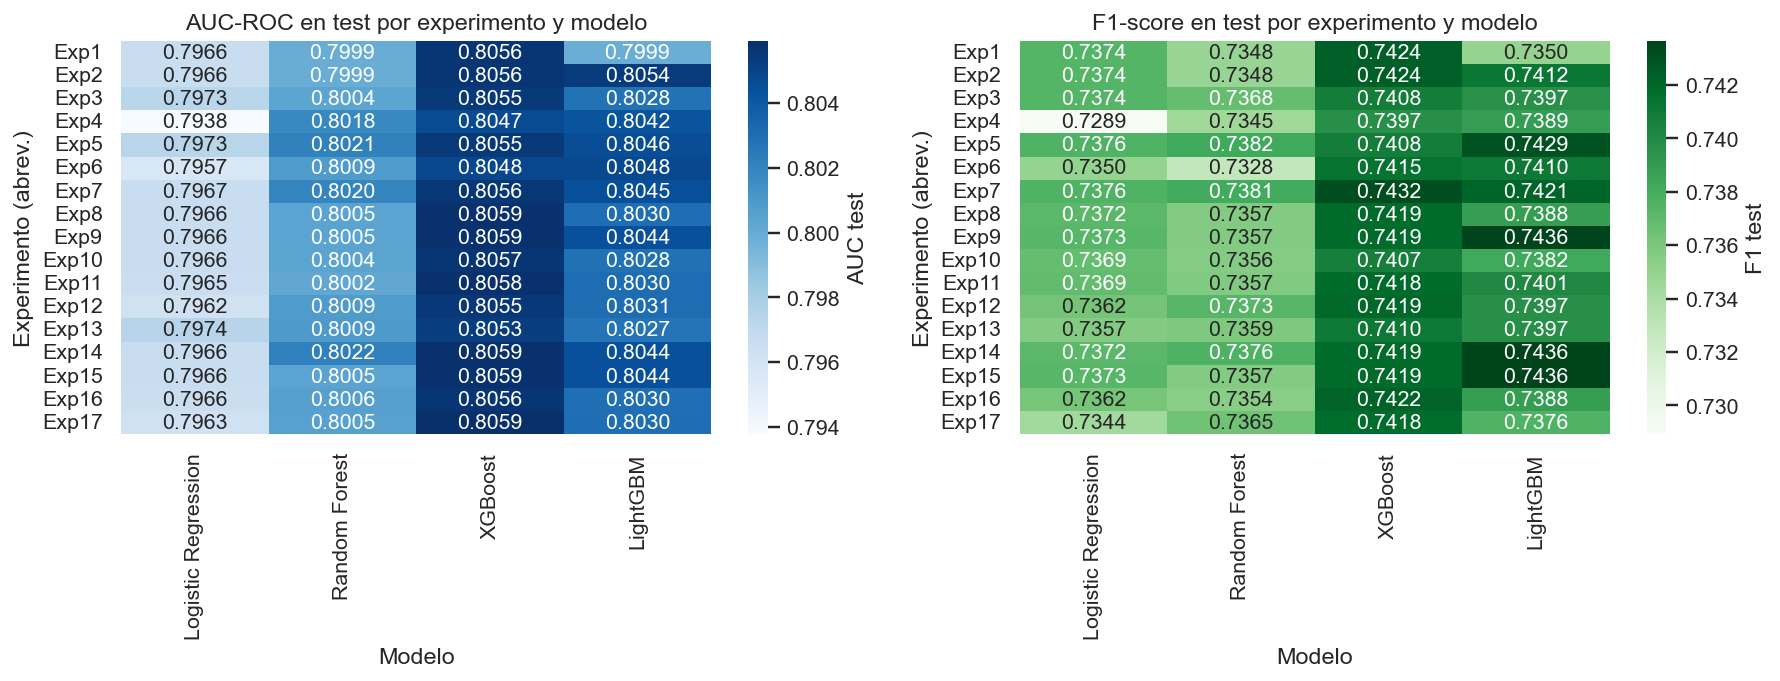

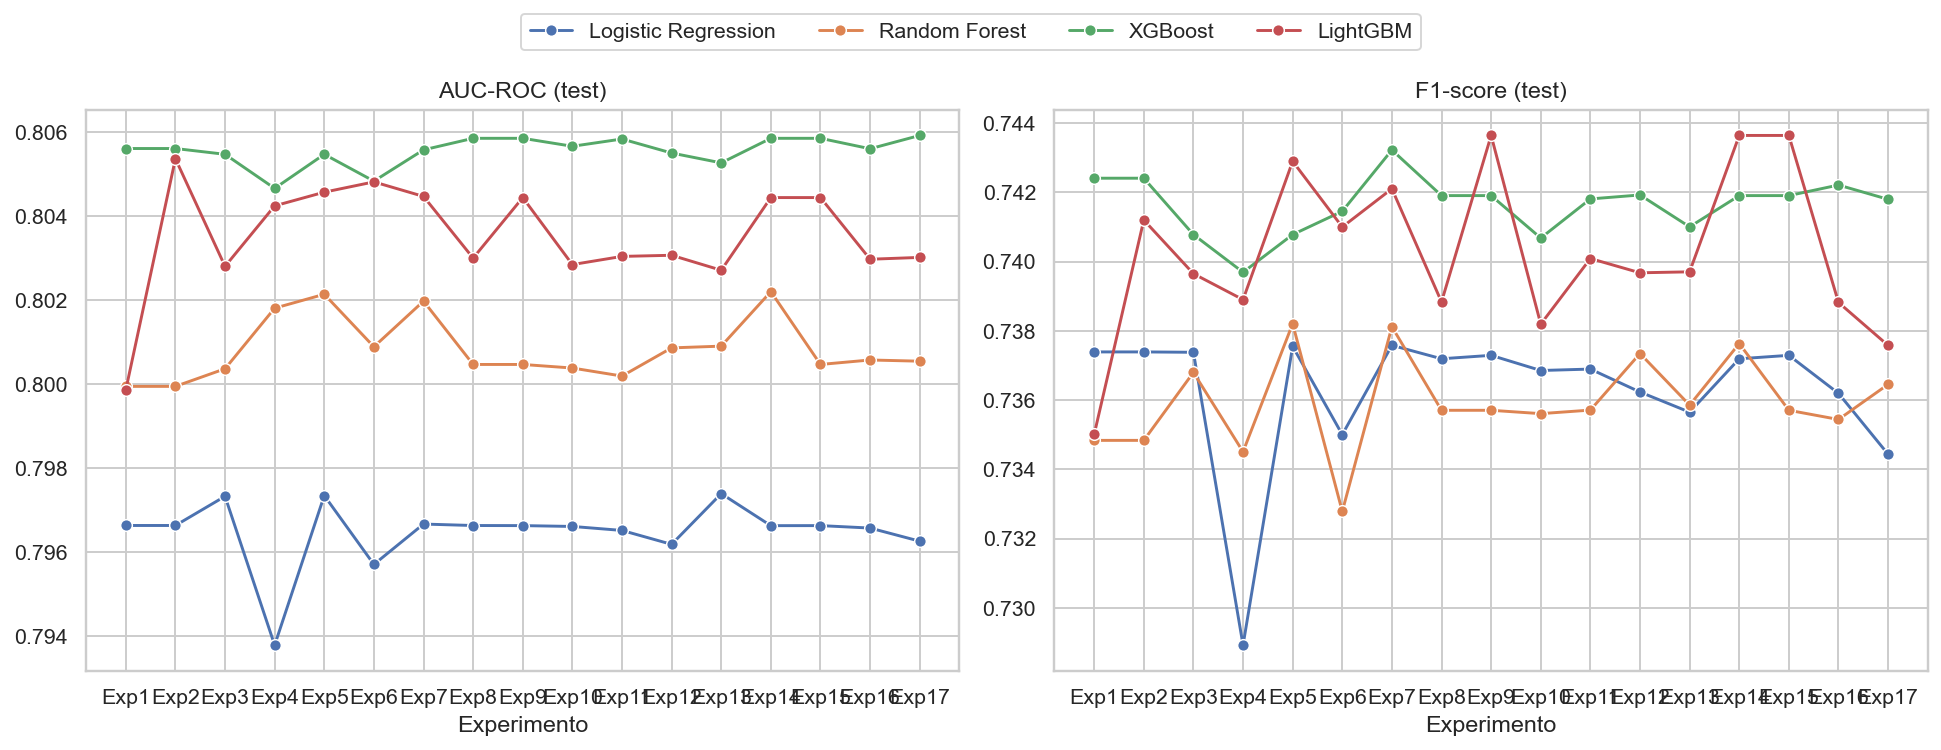

In [26]:
ordered_experiments = sorted(results_df['experiment'].unique(), key=lambda n: int(exp_pattern.match(n).group(1)))
exp_alias = {exp: f"Exp{int(exp_pattern.match(exp).group(1))}" for exp in ordered_experiments}

heat_auc = results_df.pivot(index='experiment', columns='model_name', values='test_roc_auc').reindex(index=ordered_experiments)
heat_f1 = results_df.pivot(index='experiment', columns='model_name', values='test_f1').reindex(index=ordered_experiments)

existing_cols = [c for c in MODEL_ORDER if c in heat_auc.columns]
heat_auc = heat_auc[existing_cols]
heat_f1 = heat_f1[existing_cols]

heat_auc.index = [exp_alias[e] for e in heat_auc.index]
heat_f1.index = [exp_alias[e] for e in heat_f1.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(heat_auc, annot=True, fmt='.4f', cmap='Blues', ax=axes[0], cbar_kws={'label': 'AUC test'})
axes[0].set_title('AUC-ROC en test por experimento y modelo')
axes[0].set_xlabel('Modelo')
axes[0].set_ylabel('Experimento (abrev.)')

sns.heatmap(heat_f1, annot=True, fmt='.4f', cmap='Greens', ax=axes[1], cbar_kws={'label': 'F1 test'})
axes[1].set_title('F1-score en test por experimento y modelo')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('Experimento (abrev.)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'comparativa_heatmaps_auc_f1.png', bbox_inches='tight')
plt.show()

trend_df = results_df.sort_values('experiment_number').copy()
trend_df['experiment_abbr'] = trend_df['experiment'].map(exp_alias)
metrics_for_trend = ['test_roc_auc', 'test_f1']
titles = ['AUC-ROC (test)', 'F1-score (test)']

exp_ticks = (
    trend_df[['experiment_number', 'experiment_abbr']]
    .drop_duplicates()
    .sort_values('experiment_number')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for ax, metric, title in zip(axes, metrics_for_trend, titles):
    sns.lineplot(
        data=trend_df,
        x='experiment_number',
        y=metric,
        hue='model_name',
        hue_order=MODEL_ORDER,
        marker='o',
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('Experimento')
    ax.set_ylabel('')
    ax.set_xticks(exp_ticks['experiment_number'])
    ax.set_xticklabels(exp_ticks['experiment_abbr'])

handles, labels = axes[-1].get_legend_handles_labels()
for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=True, bbox_to_anchor=(0.5, 1.08))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'comparativa_tendencias_metricas.png', bbox_inches='tight')
plt.show()

## 7. Curvas ROC de ganadores por experimento
Se grafica el mejor modelo de cada experimento para comparar separacion de clases en test.

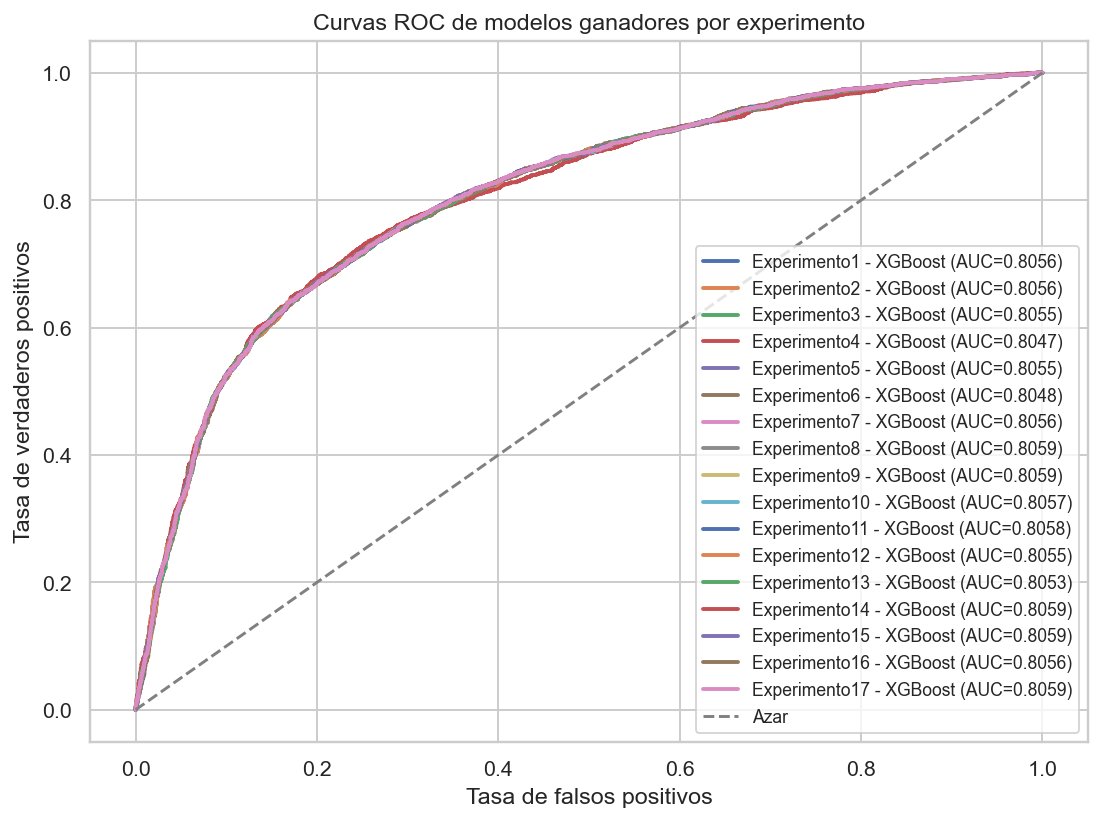

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
for row in winners_df.itertuples(index=False):
    key = (row.experiment, row.model_key)
    y_true_exp = pred_store[key]['y_true']
    y_proba = pred_store[key]['y_proba']
    fpr, tpr, _ = roc_curve(y_true_exp, y_proba)
    ax.plot(fpr, tpr, lw=2, label=f"{row.experiment} - {row.model_name} (AUC={row.test_roc_auc:.4f})")

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1.5, label='Azar')
ax.set_title('Curvas ROC de modelos ganadores por experimento')
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'roc_ganadores_por_experimento.png', bbox_inches='tight')
plt.show()

## 8. Matriz de confusion y reporte del campeon global

,Pred 0,Pred 1
Real 0,2002,1460
Real 1,531,2860


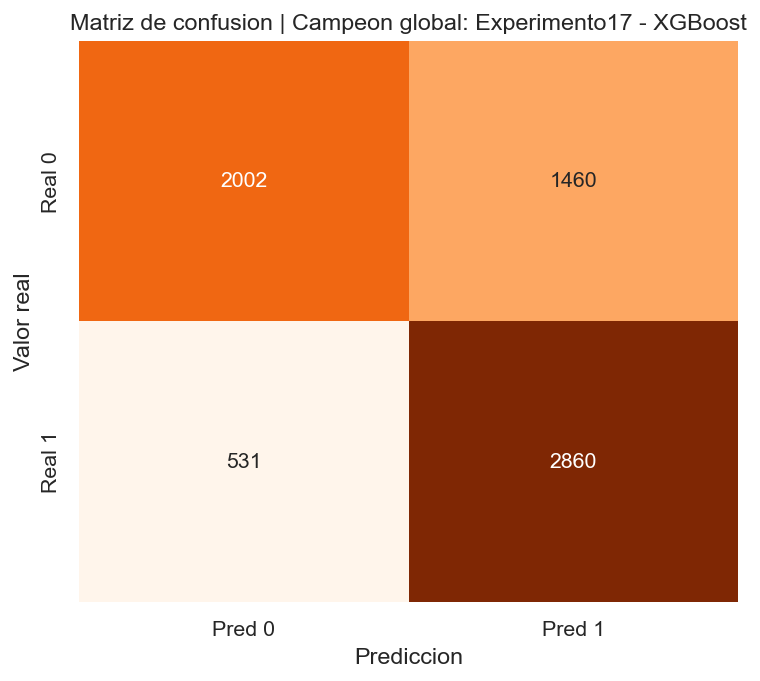

,precision,recall,f1-score,support
0,0.7904,0.5783,0.6679,3462.0000
1,0.6620,0.8434,0.7418,3391.0000
accuracy,0.7095,0.7095,0.7095,0.7095
macro avg,0.7262,0.7108,0.7048,6853.0000
weighted avg,0.7269,0.7095,0.7045,6853.0000


In [28]:
champion_key = (champion_row['experiment'], champion_row['model_key'])
champion_true = pred_store[champion_key]['y_true']
champion_pred = pred_store[champion_key]['y_pred']

cm = confusion_matrix(champion_true, champion_pred)
cm_df = pd.DataFrame(cm, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1'])
display(cm_df)

fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=ax)
ax.set_title(
    f"Matriz de confusion | Campeon global: {champion_row['experiment']} - {champion_row['model_name']}"
)
ax.set_xlabel('Prediccion')
ax.set_ylabel('Valor real')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'matriz_confusion_campeon_global.png', bbox_inches='tight')
plt.show()

report_dict = classification_report(champion_true, champion_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
display(report_df.round(4))

## 9. Analisis de caracteristicas
Se examinan caracteristicas del set de test y la importancia promedio de variables en modelos ganadores por experimento.

,mean,std,min,25%,50%,75%,max
age,-0.0724,0.6717,-2.4218,-0.5619,-0.0024,0.4321,1.0843
gender,0.3432,0.4748,0.0000,0.0000,0.0000,1.0000,1.0000
height,-0.0511,0.7036,-3.1818,-0.5455,0.0000,0.3636,3.0000
weight,0.1248,0.8494,-2.4706,-0.4118,0.0000,0.5882,7.5294
ap_hi,0.3249,0.8280,-2.0000,0.0000,0.0000,1.0000,5.0000
ap_lo,0.1181,0.9264,-3.0000,0.0000,0.0000,1.0000,5.0000
cholesterol,0.3512,0.6636,0.0000,0.0000,0.0000,0.0000,2.0000
gluc,0.2151,0.5579,0.0000,0.0000,0.0000,0.0000,2.0000
smoke,0.0871,0.2820,0.0000,0.0000,0.0000,0.0000,1.0000
alco,0.0543,0.2266,0.0000,0.0000,0.0000,0.0000,1.0000


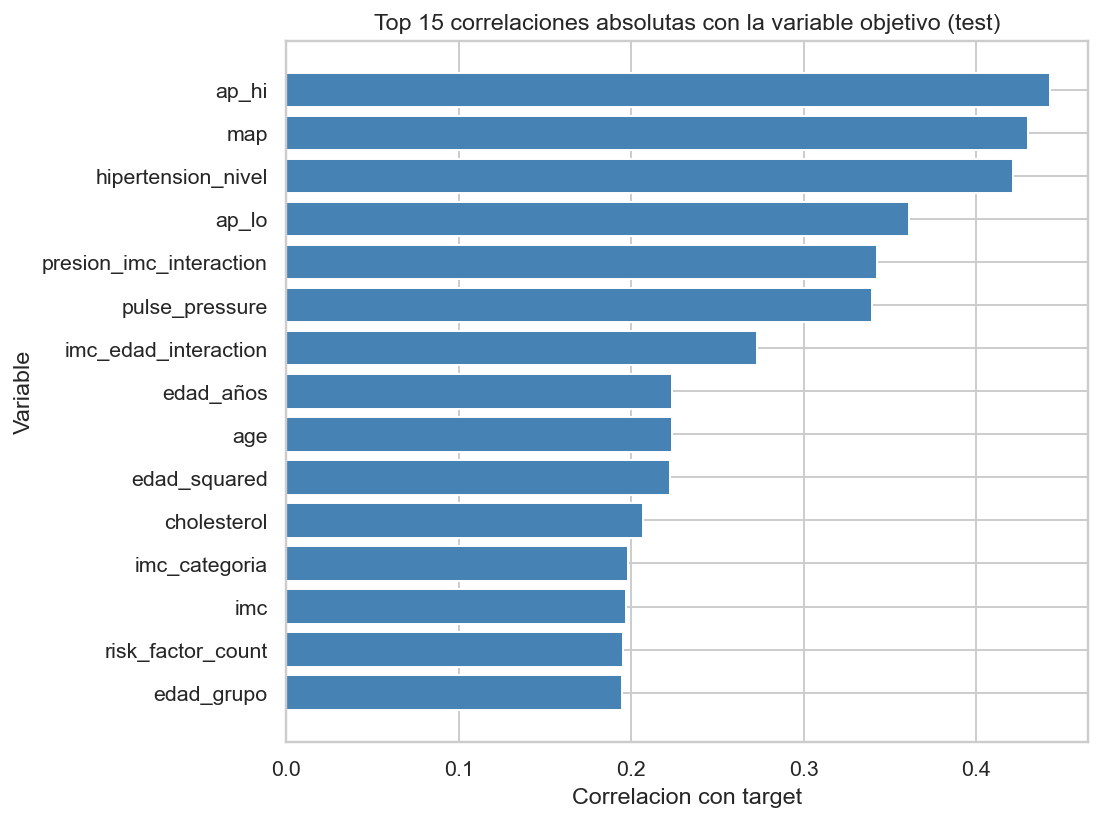

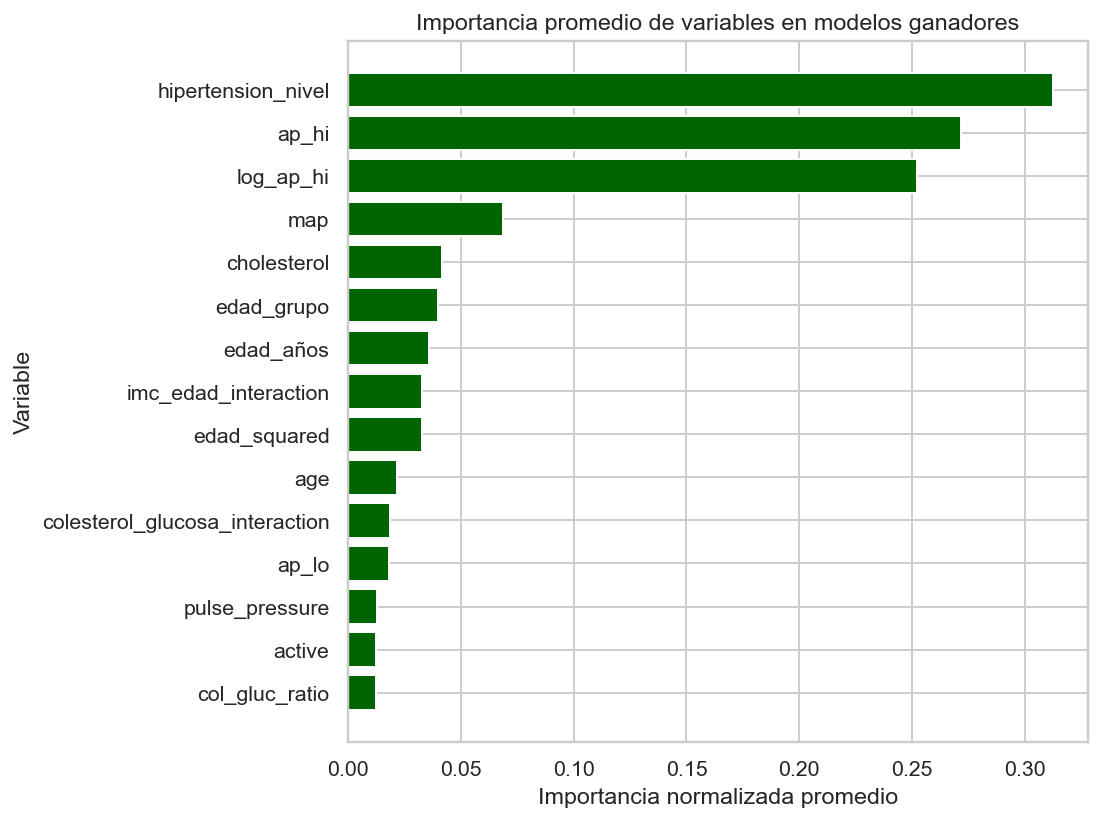

,feature,importance
14,hipertension_nivel,0.31226
3,ap_hi,0.27174
20,log_ap_hi,0.25229
21,map,0.06876
5,cholesterol,0.04180
9,edad_grupo,0.03973
8,edad_años,0.03587
17,imc_edad_interaction,0.03284
10,edad_squared,0.03280
1,age,0.02179


In [29]:
feature_summary = X_test.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
display(feature_summary.round(4).head(15))

corr_df = X_test.copy()
corr_df['target'] = y_test
corr_target = (
    corr_df.corr(numeric_only=True)['target']
    .drop('target')
    .sort_values(key=np.abs, ascending=False)
)

top_corr = corr_target.head(15).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_corr.index, top_corr.values, color='steelblue')
ax.set_title('Top 15 correlaciones absolutas con la variable objetivo (test)')
ax.set_xlabel('Correlacion con target')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_correlaciones_test.png', bbox_inches='tight')
plt.show()

winner_importances = []
for row in winners_df.itertuples(index=False):
    key = (row.experiment, row.model_key)
    if key in importance_store:
        winner_importances.append(importance_store[key].copy())

if winner_importances:
    winner_imp_df = pd.concat(winner_importances, ignore_index=True)
    agg_imp = (
        winner_imp_df.groupby('feature', as_index=False)['importance']
        .mean()
        .sort_values('importance', ascending=False)
    )

    top_imp = agg_imp.head(15).sort_values('importance')
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top_imp['feature'], top_imp['importance'], color='darkgreen')
    ax.set_title('Importancia promedio de variables en modelos ganadores')
    ax.set_xlabel('Importancia normalizada promedio')
    ax.set_ylabel('Variable')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'importancia_promedio_ganadores.png', bbox_inches='tight')
    plt.show()

    display(agg_imp.head(20).round(5))
else:
    print('No fue posible extraer importancia de variables para los modelos ganadores.')

## 10. Exportacion de resultados y resumen final

In [30]:
results_output = TABLES_DIR / 'comparativa_experimentos_test.csv'
winners_output = TABLES_DIR / 'ganadores_por_experimento_test.csv'

results_df.to_csv(results_output, index=False)
winners_df.to_csv(winners_output, index=False)

print(f'Tabla global exportada en: {results_output}')
print(f'Tabla de ganadores exportada en: {winners_output}')

print('Resumen ejecutivo:')
print(f"- Campeon global: {champion_row['experiment']} | {champion_row['model_name']}")
print(f"- AUC test: {champion_row['test_roc_auc']:.4f}")
print(f"- F1 test: {champion_row['test_f1']:.4f}")
print(f"- MCC test: {champion_row['test_mcc']:.4f}")

if not np.isnan(champion_row['val_roc_auc']):
    print(f"- Delta Test-Val (AUC): {champion_row['delta_test_val_auc']:+.4f}")
else:
    print('- Delta Test-Val (AUC): no disponible')

Tabla global exportada en: C:\Users\LENOVO\Documents\Jhandry U\Prediccion_Cardiovascular\report\tables\comparativa_experimentos_test.csv
Tabla de ganadores exportada en: C:\Users\LENOVO\Documents\Jhandry U\Prediccion_Cardiovascular\report\tables\ganadores_por_experimento_test.csv
Resumen ejecutivo:
- Campeon global: Experimento17 | XGBoost
- AUC test: 0.8059
- F1 test: 0.7418
- MCC test: 0.4368
- Delta Test-Val (AUC): +0.0044
